<a href="https://colab.research.google.com/github/JIUCHOI/zuzuggongzu/blob/main/3%EC%A3%BC%EC%B0%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Markdown Cell 1. 프로젝트 소개

# Exploratory analysis of RNA abundance and ribosome occupancy after Lin28a knockdown

지난 Mission 3에서는 LIN28A CLIP-seq 데이터를 이용하여 Mirlet7g, Mirlet7d, Mirlet7f-1 주변의 CIMS 후보 위치를 Shannon entropy 기반으로 확인하였다.  
이번 분석에서는 같은 데이터셋 안의 RNA-seq과 ribosome profiling 데이터를 이용하여 Lin28a knockdown 후 RNA abundance와 ribosome occupancy가 어떻게 달라지는지 탐험적으로 분석한다.

분석 질문은 다음과 같다.

1. siLuc control과 siLin28a knockdown 사이에서 RNA abundance가 변하는 gene은 무엇인가?
2. 같은 조건에서 ribosome footprint, 즉 RPF signal이 변하는 gene은 무엇인가?
3. RNA 변화보다 RPF 변화가 더 큰 gene은 translation-level regulation 후보로 볼 수 있는가?
4. 변화가 큰 gene list를 pathway/GO enrichment 분석에 사용할 수 있는가?

이 분석은 replicate가 충분한 formal differential expression analysis가 아니라, 수업에서 배운 EDA 관점의 exploratory analysis로 해석한다.

Code Cell 1. Google Drive 마운트와 작업 폴더 이동

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os
import glob

WORK_DIR = '/content/drive/MyDrive/binfo1-work'
os.makedirs(WORK_DIR, exist_ok=True)

candidate_dirs = [
    '/content/drive/MyDrive/binfo1-datapack1',
    '/content/drive/MyDrive/binfo1-work',
    '/content/drive/MyDrive',
]

required_files = [
    'RNA-siLuc.bam',
    'RNA-siLin28a.bam',
    'RPF-siLuc.bam',
    'RPF-siLin28a.bam',
    'CLIP-35L33G.bam',
    'gencode.gtf'
]

def has_required_files(folder):
    return all(os.path.exists(os.path.join(folder, f)) for f in required_files)

DATA_DIR = None

for folder in candidate_dirs:
    if os.path.exists(folder):
        print(f'Checking: {folder}')
        existing = [f for f in required_files if os.path.exists(os.path.join(folder, f))]
        print('  found:', existing)

        if has_required_files(folder):
            DATA_DIR = folder
            break

if DATA_DIR is None:
    print("\n기본 후보 폴더에서 전체 파일을 못 찾았습니다.")
    print("Google Drive 안에서 RNA-siLuc.bam 위치를 검색합니다. 시간이 조금 걸릴 수 있습니다.")

    hits = glob.glob('/content/drive/MyDrive/**/RNA-siLuc.bam', recursive=True)

    if len(hits) == 0:
        raise FileNotFoundError(
            "RNA-siLuc.bam을 Google Drive에서 찾지 못했습니다. "
            "binfo1-datapack1 shortcut이 사라졌거나 데이터 복사가 안 된 상태일 수 있습니다."
        )

    DATA_DIR = os.path.dirname(hits[0])

print("\n사용할 DATA_DIR:")
print(DATA_DIR)

os.chdir(WORK_DIR)

print("\nCurrent working directory:")
print(os.getcwd())

print("\nDATA_DIR 파일 확인:")
!ls -lh "$DATA_DIR" | grep -E 'RNA-|RPF-|CLIP-|gencode.gtf'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking: /content/drive/MyDrive/binfo1-datapack1
  found: ['RNA-siLuc.bam', 'RNA-siLin28a.bam', 'RPF-siLuc.bam', 'RPF-siLin28a.bam', 'CLIP-35L33G.bam', 'gencode.gtf']

사용할 DATA_DIR:
/content/drive/MyDrive/binfo1-datapack1

Current working directory:
/content/drive/MyDrive/binfo1-work

DATA_DIR 파일 확인:


In [5]:
!ls -lh {DATA_DIR}

lrw------- 1 root root 0 May  7 10:12 /content/drive/MyDrive/binfo1-datapack1 -> /content/drive/.shortcut-targets-by-id/1QBJednh-C7A17PFOlpZHBKyDmBvd6klh/binfo1-datapack1


Code Cell 2. 필요한 프로그램 설치 확인

In [6]:
!apt-get update -qq
!apt-get install -y samtools subread

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
samtools is already the newest version (1.13-4).
subread is already the newest version (2.0.3+dfsg-1).
0 upgraded, 0 newly installed, 0 to remove and 14 not upgraded.


In [7]:
!samtools --version
!featureCounts -v

samtools 1.13
Using htslib 1.13+ds
Copyright (C) 2021 Genome Research Ltd.

Samtools compilation details:
    Features:       build=configure curses=yes 
    CC:             gcc
    CPPFLAGS:       -frelease  -Wdate-time -D_FORTIFY_SOURCE=2
    CFLAGS:         -g -O2 -ffile-prefix-map=�BUILDPATH�=. -flto=auto -ffat-lto-objects -fstack-protector-strong -Wformat -Werror=format-security
    LDFLAGS:        -Wl,-Bsymbolic-functions -flto=auto -Wl,-z,relro -Wl,-z,now
    HTSDIR:         
    LIBS:           
    CURSES_LIB:     -lcurses

HTSlib compilation details:
    Features:       build=configure plugins=yes, plugin-path=/usr/local/lib/htslib:/usr/local/libexec/htslib:: libcurl=yes S3=yes GCS=yes libdeflate=yes lzma=yes bzip2=yes htscodecs=1.1.1
    CC:             gcc
    CPPFLAGS:       -I. -DSAMTOOLS=1 -Wdate-time -D_FORTIFY_SOURCE=2
    CFLAGS:         -g -O2 -ffile-prefix-map=/build/htslib-TQtOKr/htslib-1.13+ds=. -flto=auto -ffat-lto-objects -fstack-protector-strong -Wformat -Werro

Code Cell 3. featureCounts 실행

In [8]:
GTF = f'{DATA_DIR}/gencode.gtf'

!featureCounts \
    -a {GTF} \
    -o gene_counts.txt \
    -t exon \
    -g gene_id \
    {DATA_DIR}/RNA-siLuc.bam \
    {DATA_DIR}/RNA-siLin28a.bam \
    {DATA_DIR}/RPF-siLuc.bam \
    {DATA_DIR}/RPF-siLin28a.bam


        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.0.3

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 4 BAM files                                      ||
||                                                                            ||
||                           RNA-siLuc.bam                                    ||
||                           RNA-siLin28a.bam                                 ||
||                           RPF-siLuc.bam                       

Cell 4. featureCounts 결과 불러오기

In [9]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

counts_raw = pd.read_csv(
    'gene_counts.txt',
    sep='\t',
    comment='#'
)

counts_raw.head()

,Geneid,Chr,Start,End,Strand,Length,/content/drive/MyDrive/binfo1-datapack1/RNA-siLuc.bam,/content/drive/MyDrive/binfo1-datapack1/RNA-siLin28a.bam,/content/drive/MyDrive/binfo1-datapack1/RPF-siLuc.bam,/content/drive/MyDrive/binfo1-datapack1/RPF-siLin28a.bam
0,ENSMUSG00000102693.2,chr1,3143476,3144545,+,1070,0,0,0,0
1,ENSMUSG00000064842.3,chr1,3172239,3172348,+,110,0,0,0,0
2,ENSMUSG00000051951.6,chr1;chr1;chr1;chr1;chr1;chr1;chr1,3276124;3276746;3283662;3283832;3284705;349192...,3277540;3277540;3285855;3286567;3287191;349212...,-;-;-;-;-;-;-,6094,1,1,0,0
3,ENSMUSG00000102851.2,chr1,3322980,3323459,+,480,0,0,0,0
4,ENSMUSG00000103377.2,chr1,3435954,3438772,-,2819,0,0,0,0


Cell 5. featureCounts summary 확인

In [10]:
summary = pd.read_csv(
    'gene_counts.txt.summary',
    sep='\t',
    index_col=0
)

summary.columns = [os.path.basename(c).replace('.bam', '') for c in summary.columns]

display(summary)

assigned = summary.loc['Assigned']
total = summary.sum(axis=0)
assigned_rate = assigned / total * 100

assigned_table = pd.DataFrame({
    'assigned_reads': assigned,
    'total_alignments': total,
    'assigned_percent': assigned_rate
})

display(assigned_table)

,RNA-siLuc,RNA-siLin28a,RPF-siLuc,RPF-siLin28a
Status,,,,
Assigned,9748787,12338280,12932285,10694162
Unassigned_Unmapped,2331467,2169478,995087,917228
Unassigned_Read_Type,0,0,0,0
Unassigned_Singleton,0,0,0,0
Unassigned_MappingQuality,0,0,0,0
Unassigned_Chimera,0,0,0,0
Unassigned_FragmentLength,0,0,0,0
Unassigned_Duplicate,0,0,0,0
Unassigned_MultiMapping,13999092,18072245,26408669,16675170


,assigned_reads,total_alignments,assigned_percent
RNA-siLuc,9748787,28117241,34.671919
RNA-siLin28a,12338280,35108178,35.143607
RPF-siLuc,12932285,42002435,30.789370
RPF-siLin28a,10694162,30095551,35.534030


Cell 6. count table column 이름 정리

In [11]:
meta_cols = ['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length']
count_cols = [c for c in counts_raw.columns if c not in meta_cols]

def rename_count_column(col):
    name = os.path.basename(col)

    if name == 'RNA-siLuc.bam':
        return 'RNA_siLuc'
    elif name == 'RNA-siLin28a.bam':
        return 'RNA_siLin28a'
    elif name == 'RPF-siLuc.bam':
        return 'RPF_siLuc'
    elif name == 'RPF-siLin28a.bam':
        return 'RPF_siLin28a'
    else:
        return name.replace('.bam', '')

rename_map = {c: rename_count_column(c) for c in count_cols}

counts = counts_raw.rename(columns=rename_map)

sample_cols = [
    'RNA_siLuc',
    'RNA_siLin28a',
    'RPF_siLuc',
    'RPF_siLin28a'
]

counts[['Geneid', 'Length'] + sample_cols].head()

,Geneid,Length,RNA_siLuc,RNA_siLin28a,RPF_siLuc,RPF_siLin28a
0,ENSMUSG00000102693.2,1070,0,0,0,0
1,ENSMUSG00000064842.3,110,0,0,0,0
2,ENSMUSG00000051951.6,6094,1,1,0,0
3,ENSMUSG00000102851.2,480,0,0,0,0
4,ENSMUSG00000103377.2,2819,0,0,0,0


Cell 7. GTF에서 gene_name 붙이기

In [12]:
GTF = f'{DATA_DIR}/gencode.gtf'

def parse_gtf_attributes(attr):
    result = {}
    for key, value in re.findall(r'(\S+) "([^"]+)"', attr):
        result[key] = value
    return result

gene_info = []

with open(GTF) as f:
    for line in f:
        if line.startswith('#'):
            continue

        fields = line.rstrip('\n').split('\t')
        if len(fields) < 9:
            continue

        chrom, source, feature, start, end, score, strand, frame, attrs = fields

        if feature != 'gene':
            continue

        attr_dict = parse_gtf_attributes(attrs)

        gene_info.append({
            'Geneid': attr_dict.get('gene_id'),
            'gene_name': attr_dict.get('gene_name'),
            'gene_type': attr_dict.get('gene_type'),
            'gene_chrom': chrom,
            'gene_start': int(start),
            'gene_end': int(end),
            'gene_strand': strand
        })

gene_info = pd.DataFrame(gene_info)

counts_annot = counts.merge(gene_info, on='Geneid', how='left')

counts_annot[['Geneid', 'gene_name', 'gene_type', 'Length'] + sample_cols].head()

,Geneid,gene_name,gene_type,Length,RNA_siLuc,RNA_siLin28a,RPF_siLuc,RPF_siLin28a
0,ENSMUSG00000102693.2,4933401J01Rik,TEC,1070,0,0,0,0
1,ENSMUSG00000064842.3,Gm26206,snRNA,110,0,0,0,0
2,ENSMUSG00000051951.6,Xkr4,protein_coding,6094,1,1,0,0
3,ENSMUSG00000102851.2,Gm18956,processed_pseudogene,480,0,0,0,0
4,ENSMUSG00000103377.2,Gm37180,TEC,2819,0,0,0,0


Cell 8. Library size 확인

In [13]:
library_sizes = counts_annot[sample_cols].sum(axis=0)

library_sizes

,0
RNA_siLuc,9748787
RNA_siLin28a,12338280
RPF_siLuc,12932285
RPF_siLin28a,10694162


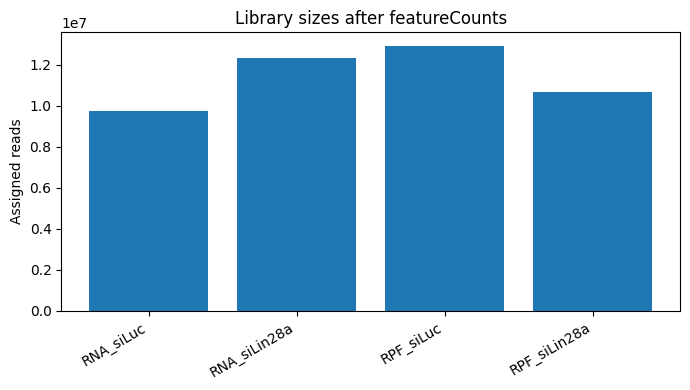

In [14]:
plt.figure(figsize=(7, 4))
plt.bar(library_sizes.index, library_sizes.values)
plt.ylabel('Assigned reads')
plt.title('Library sizes after featureCounts')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('Figure1_library_sizes.png', dpi=150)
plt.show()

Cell 9. CPM normalization

In [15]:
cpm = counts_annot[sample_cols].divide(library_sizes, axis=1) * 1_000_000

for col in sample_cols:
    counts_annot[col + '_CPM'] = cpm[col]

cpm_cols = [col + '_CPM' for col in sample_cols]

counts_annot[['Geneid', 'gene_name', 'gene_type'] + cpm_cols].head()

,Geneid,gene_name,gene_type,RNA_siLuc_CPM,RNA_siLin28a_CPM,RPF_siLuc_CPM,RPF_siLin28a_CPM
0,ENSMUSG00000102693.2,4933401J01Rik,TEC,0.000000,0.000000,0.0,0.0
1,ENSMUSG00000064842.3,Gm26206,snRNA,0.000000,0.000000,0.0,0.0
2,ENSMUSG00000051951.6,Xkr4,protein_coding,0.102577,0.081049,0.0,0.0
3,ENSMUSG00000102851.2,Gm18956,processed_pseudogene,0.000000,0.000000,0.0,0.0
4,ENSMUSG00000103377.2,Gm37180,TEC,0.000000,0.000000,0.0,0.0


Cell 10. 분석에 사용할 expressed gene 필터링

In [16]:
expressed = counts_annot[
    counts_annot[cpm_cols].max(axis=1) >= 1
].copy()

print("All genes:", len(counts_annot))
print("Expressed genes used for analysis:", len(expressed))

All genes: 55359
Expressed genes used for analysis: 16944


Cell 11. RNA log2FC, RPF log2FC, delta score 계산

In [17]:
pseudo = 1

expressed['RNA_log2FC'] = np.log2(
    (expressed['RNA_siLin28a_CPM'] + pseudo) /
    (expressed['RNA_siLuc_CPM'] + pseudo)
)

expressed['RPF_log2FC'] = np.log2(
    (expressed['RPF_siLin28a_CPM'] + pseudo) /
    (expressed['RPF_siLuc_CPM'] + pseudo)
)

expressed['delta_RPF_minus_RNA'] = (
    expressed['RPF_log2FC'] - expressed['RNA_log2FC']
)

expressed['mean_RNA_CPM'] = expressed[
    ['RNA_siLuc_CPM', 'RNA_siLin28a_CPM']
].mean(axis=1)

expressed['mean_RPF_CPM'] = expressed[
    ['RPF_siLuc_CPM', 'RPF_siLin28a_CPM']
].mean(axis=1)

expressed[
    ['Geneid', 'gene_name', 'gene_type',
     'RNA_log2FC', 'RPF_log2FC', 'delta_RPF_minus_RNA']
].head()

,Geneid,gene_name,gene_type,RNA_log2FC,RPF_log2FC,delta_RPF_minus_RNA
10,ENSMUSG00000103161.2,Gm38148,TEC,-0.432192,0.000000,0.432192
15,ENSMUSG00000102343.2,Gm37381,lncRNA,0.055635,-0.078493,-0.134127
21,ENSMUSG00000102269.2,Gm7357,processed_pseudogene,0.619276,-0.514737,-1.134013
26,ENSMUSG00000098104.2,Gm6085,processed_pseudogene,0.291581,-0.376788,-0.668369
30,ENSMUSG00000103922.2,Gm6123,processed_pseudogene,-0.399022,-0.464596,-0.065574


RNA_log2FC = Lin28a knockdown 후 RNA abundance 변화 /
RPF_log2FC = Lin28a knockdown 후 ribosome footprint 변화 /
delta_RPF_minus_RNA = RNA 변화로 설명되지 않는 RPF 변화

Cell 12. 결과 table 저장

In [18]:
result_cols = [
    'Geneid', 'gene_name', 'gene_type', 'Length',
    'RNA_siLuc', 'RNA_siLin28a',
    'RPF_siLuc', 'RPF_siLin28a',
    'RNA_siLuc_CPM', 'RNA_siLin28a_CPM',
    'RPF_siLuc_CPM', 'RPF_siLin28a_CPM',
    'mean_RNA_CPM', 'mean_RPF_CPM',
    'RNA_log2FC', 'RPF_log2FC', 'delta_RPF_minus_RNA'
]

result_table = expressed[result_cols].copy()

result_table.to_csv(
    'RNA_RPF_Lin28a_knockdown_exploratory_results.csv',
    index=False
)

result_table.head()

,Geneid,gene_name,gene_type,Length,RNA_siLuc,RNA_siLin28a,RPF_siLuc,RPF_siLin28a,RNA_siLuc_CPM,RNA_siLin28a_CPM,RPF_siLuc_CPM,RPF_siLin28a_CPM,mean_RNA_CPM,mean_RPF_CPM,RNA_log2FC,RPF_log2FC,delta_RPF_minus_RNA
10,ENSMUSG00000103161.2,Gm38148,TEC,3012,13,9,0,0,1.333499,0.729437,0.000000,0.000000,1.031468,0.000000,-0.432192,0.000000,0.432192
15,ENSMUSG00000102343.2,Gm37381,lncRNA,1364,157,207,2,1,16.104568,16.777055,0.154652,0.093509,16.440811,0.124080,0.055635,-0.078493,-0.134127
21,ENSMUSG00000102269.2,Gm7357,processed_pseudogene,2991,11,28,9,2,1.128346,2.269360,0.695933,0.187018,1.698853,0.441475,0.619276,-0.514737,-1.134013
26,ENSMUSG00000098104.2,Gm6085,processed_pseudogene,1470,15,26,7,2,1.538653,2.107263,0.541281,0.187018,1.822958,0.364149,0.291581,-0.376788,-0.668369
30,ENSMUSG00000103922.2,Gm6123,processed_pseudogene,1069,100,93,75,42,10.257686,7.537517,5.799439,3.927376,8.897602,4.863408,-0.399022,-0.464596,-0.065574


Cell 13. RNA 변화 vs RPF 변화 scatter plot

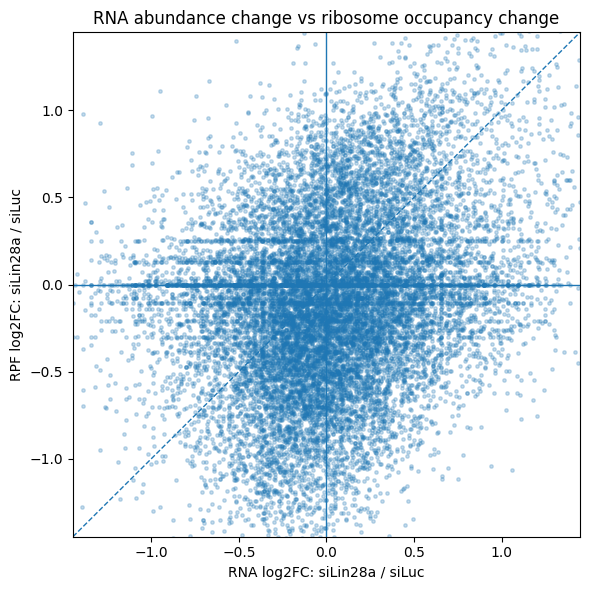

In [19]:
plt.figure(figsize=(6, 6))

plt.scatter(
    expressed['RNA_log2FC'],
    expressed['RPF_log2FC'],
    s=6,
    alpha=0.25
)

lim = max(
    np.nanquantile(np.abs(expressed['RNA_log2FC']), 0.99),
    np.nanquantile(np.abs(expressed['RPF_log2FC']), 0.99)
)

plt.xlim(-lim, lim)
plt.ylim(-lim, lim)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.plot([-lim, lim], [-lim, lim], linestyle='--', linewidth=1)

plt.xlabel('RNA log2FC: siLin28a / siLuc')
plt.ylabel('RPF log2FC: siLin28a / siLuc')
plt.title('RNA abundance change vs ribosome occupancy change')
plt.tight_layout()
plt.savefig('Figure2_RNA_vs_RPF_log2FC.png', dpi=150)
plt.show()

Cell 14. delta score 분포 보기

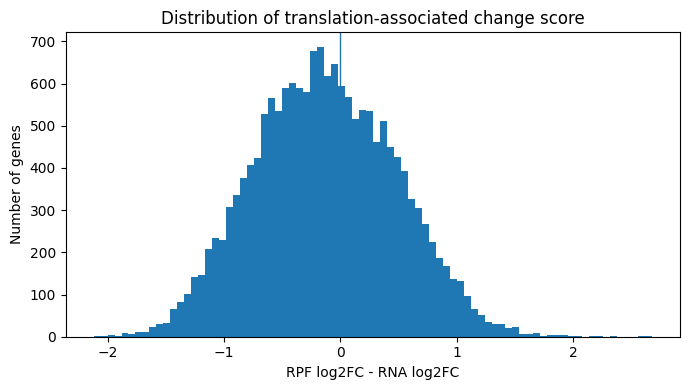

In [20]:
plt.figure(figsize=(7, 4))

plt.hist(
    expressed['delta_RPF_minus_RNA'].dropna(),
    bins=80
)

plt.axvline(0, linewidth=1)
plt.xlabel('RPF log2FC - RNA log2FC')
plt.ylabel('Number of genes')
plt.title('Distribution of translation-associated change score')
plt.tight_layout()
plt.savefig('Figure3_delta_RPF_minus_RNA_distribution.png', dpi=150)
plt.show()

Cell 15. 후보 gene 확인

In [21]:
top_positive = expressed.sort_values(
    'delta_RPF_minus_RNA',
    ascending=False
).head(20)

top_negative = expressed.sort_values(
    'delta_RPF_minus_RNA',
    ascending=True
).head(20)

print("Top positive delta_RPF_minus_RNA genes")
display(top_positive[
    ['gene_name', 'gene_type',
     'RNA_log2FC', 'RPF_log2FC', 'delta_RPF_minus_RNA',
     'mean_RNA_CPM', 'mean_RPF_CPM']
])

print("Top negative delta_RPF_minus_RNA genes")
display(top_negative[
    ['gene_name', 'gene_type',
     'RNA_log2FC', 'RPF_log2FC', 'delta_RPF_minus_RNA',
     'mean_RNA_CPM', 'mean_RPF_CPM']
])

Top positive delta_RPF_minus_RNA genes


,gene_name,gene_type,RNA_log2FC,RPF_log2FC,delta_RPF_minus_RNA,mean_RNA_CPM,mean_RPF_CPM
15194,U4,snRNA,-1.849258,0.830922,2.680181,2.980429,7.157967
41161,Gm37194,TEC,-2.302291,0.330882,2.633173,5.091486,2.834958
27870,Gm6166,processed_pseudogene,-1.586951,1.000439,2.587391,5.545485,7.113007
15195,U4,snRNA,-1.389411,0.976921,2.366333,1.249918,12.304579
2010,Gm38073,TEC,-0.691946,1.671272,2.363219,0.307731,1.254279
41115,Tmem260,protein_coding,-1.290273,0.924226,2.214499,5.051597,1.905253
2080,Cd55,protein_coding,-0.501070,1.690254,2.191323,11.757093,16.312871
15586,Nupr1l,protein_coding,-0.947443,1.107982,2.055424,5.211162,5.823655
12469,Ccnd3-ps,processed_pseudogene,-2.362211,-0.361252,2.000959,12.523879,0.783145
5831,Chac1,protein_coding,-2.197945,-0.223728,1.974217,16.287566,2.009560


Top negative delta_RPF_minus_RNA genes


,gene_name,gene_type,RNA_log2FC,RPF_log2FC,delta_RPF_minus_RNA,mean_RNA_CPM,mean_RPF_CPM
31888,Nab2,protein_coding,1.056503,-1.066194,-2.122696,9.701761,2.138142
4012,Card9,protein_coding,1.588716,-0.488618,-2.077334,1.826125,0.650973
43506,Parp10,protein_coding,1.829399,-0.209303,-2.038701,2.444754,1.086152
44098,Rapgef3,protein_coding,1.881115,-0.141220,-2.022335,7.106944,1.132906
32939,Anxa6,protein_coding,0.500096,-1.493266,-1.993362,191.889914,54.064954
20947,Gpatch1,protein_coding,0.483536,-1.499658,-1.983194,33.777594,7.893504
29890,Soga3,protein_coding,0.938358,-1.040373,-1.978731,8.086489,2.386303
39446,Gm8399,processed_pseudogene,1.200200,-0.754219,-1.954419,2.509339,0.720207
6936,Kcng1,protein_coding,1.815508,-0.082217,-1.897725,1.723548,0.799328
8609,S100a16,protein_coding,1.434038,-0.450368,-1.884406,0.851010,0.736390


Cell 16. 후보 gene 저장

In [22]:
top_positive.to_csv(
    'top_positive_delta_RPF_minus_RNA_genes.csv',
    index=False
)

top_negative.to_csv(
    'top_negative_delta_RPF_minus_RNA_genes.csv',
    index=False
)

top_candidates = pd.concat([
    top_positive.assign(direction='positive_delta'),
    top_negative.assign(direction='negative_delta')
])

top_candidates.to_csv(
    'top_candidate_translation_related_genes.csv',
    index=False
)

print("Saved files:")
print("RNA_RPF_Lin28a_knockdown_exploratory_results.csv")
print("top_positive_delta_RPF_minus_RNA_genes.csv")
print("top_negative_delta_RPF_minus_RNA_genes.csv")
print("top_candidate_translation_related_genes.csv")

Saved files:
RNA_RPF_Lin28a_knockdown_exploratory_results.csv
top_positive_delta_RPF_minus_RNA_genes.csv
top_negative_delta_RPF_minus_RNA_genes.csv
top_candidate_translation_related_genes.csv


Cell 17. 최종 파일 확인

In [23]:
!ls -lh Figure*.png *.csv gene_counts.txt gene_counts.txt.summary

-rw------- 1 root root  372 May 28 06:25 FigS2C_error_type_summary.csv
-rw------- 1 root root 6.4K May 28 06:21 FigS2C_like_error_profile_2percent.csv
-rw------- 1 root root 6.9K May 28 06:25 FigS2C_like_error_profile_full.csv
-rw------- 1 root root  528 May 28 06:21 FigS2C_like_error_summary_2percent.csv
-rw------- 1 root root  548 May 28 06:25 FigS2C_like_error_summary_full.csv
-rw------- 1 root root 2.1K May 28 06:26 FigS2D_like_base_specific_error_counts_10percent.csv
-rw------- 1 root root  562 May 28 06:26 FigS2D_like_G_enrichment_ratio.csv
-rw------- 1 root root  41K Jun  4 10:24 Figure1_library_sizes.png
-rw------- 1 root root 540K Jun  4 10:25 Figure2_RNA_vs_RPF_log2FC.png
-rw------- 1 root root  35K Jun  4 10:25 Figure3_delta_RPF_minus_RNA_distribution.png
-rw------- 1 root root  23M Jun  4 10:19 gene_counts.txt
-rw------- 1 root root  762 Jun  4 10:19 gene_counts.txt.summary
-rw------- 1 root root  25K May 13 09:40 Mirlet7d_entropy_table.csv
-rw------- 1 root root  19K May 1